In [3]:
from pandas import read_csv
import matplotlib.pyplot as plt
import numpy as np
from sklearn import preprocessing

In [4]:
df = read_csv("../../datasets/Customer_Churn.csv")
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [5]:
df['Churn'].value_counts()

Churn
0    2655
1     495
Name: count, dtype: int64

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

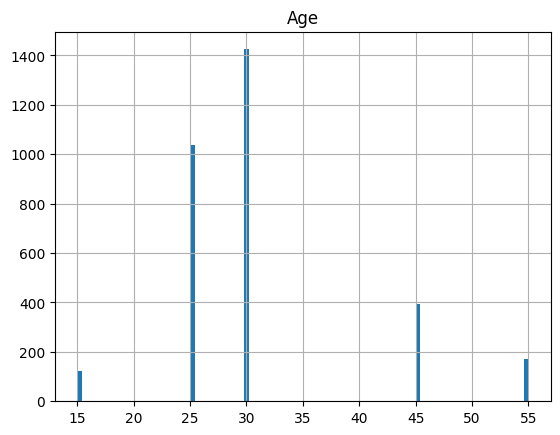

In [23]:
df.hist(column='Seconds of Use', bins=100)

In [7]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='object')

In [8]:
X = df[['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value']].values
X

array([[8.00000e+00, 0.00000e+00, 3.80000e+01, ..., 1.00000e+00,
        3.00000e+01, 1.97640e+02],
       [0.00000e+00, 0.00000e+00, 3.90000e+01, ..., 2.00000e+00,
        2.50000e+01, 4.60350e+01],
       [1.00000e+01, 0.00000e+00, 3.70000e+01, ..., 1.00000e+00,
        3.00000e+01, 1.53652e+03],
       ...,
       [1.30000e+01, 0.00000e+00, 1.80000e+01, ..., 1.00000e+00,
        3.00000e+01, 2.80320e+02],
       [7.00000e+00, 0.00000e+00, 1.10000e+01, ..., 1.00000e+00,
        3.00000e+01, 1.07764e+03],
       [8.00000e+00, 1.00000e+00, 1.10000e+01, ..., 1.00000e+00,
        3.00000e+01, 1.00680e+02]])

In [9]:
Y = df['Churn'].values
Y

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

In [10]:
scaler = preprocessing.StandardScaler().fit(X)
X = scaler.transform(X.astype(float))
print(X[0:5])

[[ 0.05122913 -0.2878304   0.63672633 -0.61996205 -0.02441119  0.02681625
  -0.60751272 -0.37815805  0.19494132 -0.29040893 -0.57466206 -0.11307444
  -0.52875851]
 [-1.05028466 -0.2878304   0.75338358 -0.61996205 -0.98980697 -1.12292553
  -0.58969054 -1.1333308  -0.92561556 -0.29040893  1.74015315 -0.67934551
  -0.82203616]
 [ 0.32660758 -0.2878304   0.52006909 -0.61996205 -0.48113965 -0.16480738
   2.54701243  0.02847342  0.19494132 -0.29040893 -0.57466206 -0.11307444
   2.0612852 ]
 [ 0.32660758 -0.2878304   0.63672633 -0.61996205 -0.06539048 -0.0602854
  -0.64315707  0.66746575 -2.04617244 -0.29040893 -0.57466206 -1.81188763
  -0.44677503]
 [-0.63721699 -0.2878304   0.63672633 -0.61996205 -0.49543475 -0.19964804
  -0.63424598  0.55128532 -2.04617244 -0.29040893 -0.57466206 -1.81188763
  -0.62903256]]


In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test = train_test_split(X, Y, test_size=0.2, random_state=3)
print("train data: ", X_train.shape, Y_train.shape)
print("test data: ", X_test.shape, Y_test.shape)

train data:  (2520, 13) (2520,)
test data:  (630, 13) (630,)


In [12]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
tree = DecisionTreeClassifier(max_depth=30).fit(x_train, y_train)
tree

DecisionTreeClassifier(max_depth=30)

In [20]:
predictTree = tree.predict(x_test)
print("Real data: ", Y[0:35])
print("Prediction: ", predicTree[0:35])

Real data:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0]
Prediction:  [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0]


In [21]:
from sklearn import metrics
print(metrics.classification_report(y_test, predictTree))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       540
           1       0.79      0.86      0.82        90

    accuracy                           0.95       630
   macro avg       0.88      0.91      0.90       630
weighted avg       0.95      0.95      0.95       630



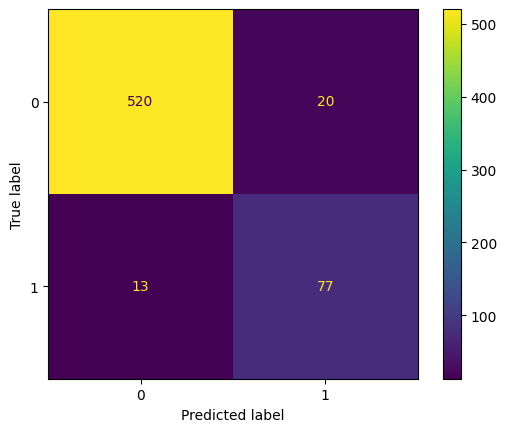

In [22]:
cm = metrics.confusion_matrix(y_test, predictTree)
disp = metrics.ConfusionMatrixDisplay(cm)
disp.plot()